# Video Game Sales Prediction - Machine Learning Lab

## Introduction and Setup
Welcome to this machine learning lab where we'll build a model to predict
whether a video game will be a "hit" based on its characteristics and sales data.
This notebook will guide you through the entire process, from data loading to
model evaluation and optimization.

Learning objectives:
1. Learn to preprocess and explore a real-world dataset
2. Build and evaluate a decision tree classifier
3. Optimize a model through hyperparameter tuning
4. Interpret model results and feature importance

In [ ]:
# Cell 1
#install libraries if necessary

# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

print("Import Libraries successfully")
print("Libraries imported successfully.")

Import Libraries successfully
Libraries imported successfully.


In [ ]:
# Cell 2
# Set random seed for reproducibility
np.random.seed(42)
print("Random seed set successfully.")

Random seed set successfully.


In [ ]:
# Cell 3
# Configure visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
print("Visualizations configured successfully.")

Visualizations configured successfully.


In [ ]:
# Cell 4
# Display settings for better output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("Display settings configured successfully.")

Display settings configured successfully.


## Download the Dataset

In [ ]:
# Cell 5
# You can run this cell to download the dataset directly, or upload it manually!
import requests

url = 'https://www.kaggle.com/datasets/gregorut/videogamesales'
response = requests.get(url)

with open('videogamesales.zip', 'wb') as f:
	f.write(response.content)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


## Load the dataset

In [ ]:
# Cell 6
# Load the dataset
import zipfile
import os

# Check if vgsales.csv already exists (meaning it's already unzipped or manually uploaded)
if os.path.exists('vgsales.csv'):
    print("'vgsales.csv' found. Loading data directly.")
else:
    print("'vgsales.csv' not found. Checking for 'videogamesales.zip'.")
    # If not, try to unzip videogamesales.zip
    if os.path.exists('videogamesales.zip'):
        try:
            with zipfile.ZipFile('videogamesales.zip', 'r') as zip_ref:
                zip_ref.extractall('.')
            print("'videogamesales.zip' successfully unzipped.")
        except zipfile.BadZipFile:
            print("Error: 'videogamesales.zip' is not a valid zip file. This usually happens if the Kaggle download failed.")
            print("Please manually download 'vgsales.csv' from Kaggle and upload it to your Colab environment.")
            # Exit or raise error if we can't proceed without the CSV
            raise FileNotFoundError("Cannot proceed without 'vgsales.csv'. Please upload it manually.")
    else:
        print("'videogamesales.zip' not found either. Please ensure you have run Cell 5 or manually uploaded 'vgsales.csv'.")
        raise FileNotFoundError("Cannot proceed without 'vgsales.csv'. Please ensure it's available.")

# Load the dataset (now that vgsales.csv should be available)
df = pd.read_csv('vgsales.csv')

# Let's take a look at the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())
print("Dataset loaded and first 5 rows displayed successfully.")

'vgsales.csv' found. Loading data directly.
First 5 rows of the dataset:
   Rank                      Name Platform    Year         Genre Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo     41.49     29.02      3.77         8.46         82.74
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo     29.08      3.58      6.81         0.77         40.24
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo     15.85     12.88      3.79         3.31         35.82
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo     15.75     11.01      3.28         2.96         33.00
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo     11.27      8.89     10.22         1.00         31.37
Dataset loaded and first 5 rows displayed successfully.


## Dataset Information

In [ ]:
# Cell 7
# Get basic information about the dataset
print("\nDataset basic information:")
print(df.info())

# Get descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())
print("Dataset information and statistics displayed successfully.")


Dataset basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None

Descriptive statistics:
               Rank          Year      NA_Sales      EU_Sales      JP_Sales   Other_Sales  Global_Sales
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000  16598.000000  16598.000000
mean

In [ ]:
# Cell 8:Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())
print("Missing values checked successfully.")


Missing values per column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Missing values checked successfully.


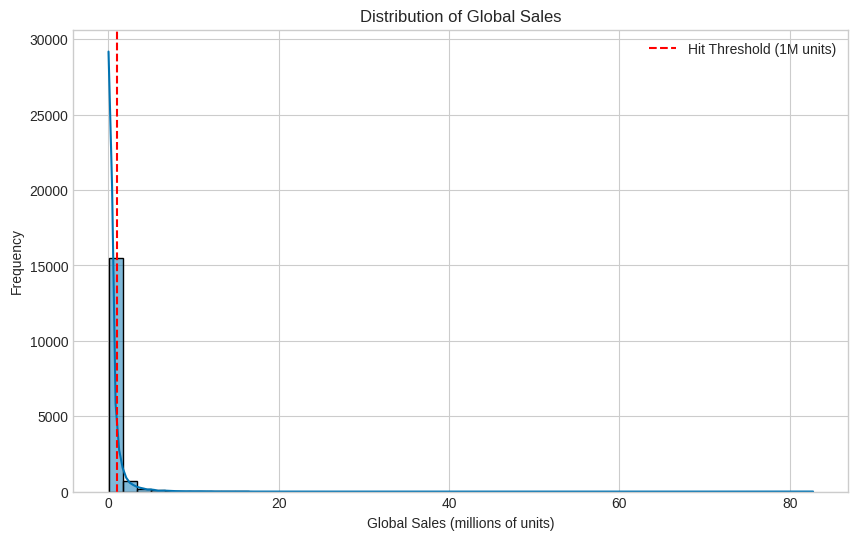

Global sales distribution visualized successfully.


In [ ]:
# Cell 9: Data Visualization - Global Sales Distribution
# ====================================================
# Visualize the distribution of global sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Global_Sales'], bins=50, kde=True)
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (millions of units)')
plt.ylabel('Frequency')
plt.axvline(x=1, color='red', linestyle='--', label='Hit Threshold (1M units)')
plt.legend()
plt.show()
print("Global sales distribution visualized successfully.")

In [ ]:
# Cell 10: Create Target Variable
# ============================
# TASK: Create a binary target variable for "hit" games
# A game is considered a hit if it sold more than 1 million units (Global_Sales > 1)

df['is_hit'] = (df['Global_Sales'] > 1).astype(int)

print("Target variable 'is_hit' created successfully.")

Target variable 'is_hit' created successfully.


In [ ]:
# Cell 11: Analyze Target Distribution
# ================================
# Let's see the proportion of hits in our dataset

print("\nDistribution of 'is_hit' variable:")
print(df['is_hit'].value_counts())

print("\nPercentage distribution of 'is_hit' variable:")
print(df['is_hit'].value_counts(normalize=True) * 100)

print("Target distribution analysis completed successfully.")


Distribution of 'is_hit' variable:
is_hit
0    14544
1     2054
Name: count, dtype: int64

Percentage distribution of 'is_hit' variable:
is_hit
0    87.625015
1    12.374985
Name: proportion, dtype: float64
Target distribution analysis completed successfully.


In [ ]:
# Cell 12: Drop Non-Informative Columns
# ==================================
# TASK: Drop non-informative columns
# Think about which columns won't help with prediction

# Initialize df_clean from the original dataframe
df_clean = df.copy()

# 'Rank' is just an index, 'Name' is unique to each game and not directly useful for prediction
# 'Global_Sales' is used to create the target variable, so it should not be a feature itself
df_clean = df_clean.drop(columns=['Rank', 'Name', 'Global_Sales'])

print("Non-informative columns dropped and df_clean initialized successfully.")

Non-informative columns dropped and df_clean initialized successfully.


In [ ]:
# Cell 13: Missing Value Analysis
# =============================
# Examine the 'Year' column which might have missing values

print("Missing values before handling:")
print(df_clean.isnull().sum())

print("Year column examination completed.")

Missing values before handling:
Platform         0
Year           271
Genre            0
Publisher       58
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
is_hit           0
dtype: int64
Year column examination completed.


In [ ]:
# Cell 14: Handle Missing Values
# ============================
# TASK: Handle missing values

# Fill missing 'Year' values with the median year
df_clean['Year'] = df_clean['Year'].fillna(df_clean['Year'].median())

# Fill missing 'Publisher' values with 'Unknown'
df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')

print("Missing values handled successfully.")
print("\nMissing values after handling:")
print(df_clean.isnull().sum())

Missing values handled successfully.

Missing values after handling:
Platform       0
Year           0
Genre          0
Publisher      0
NA_Sales       0
EU_Sales       0
JP_Sales       0
Other_Sales    0
is_hit         0
dtype: int64


In [ ]:
# Cell 15: Categorical Variable Analysis
# ===================================
# Let's identify categorical columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_columns)
print("Categorical columns identified successfully.")


Categorical columns: ['Platform', 'Genre', 'Publisher']
Categorical columns identified successfully.


In [ ]:
# Cell 16: Encode Categorical Variables
# ==================================
# TASK: Encode categorical variables using LabelEncoder
# Label Encoder transforms categorical variables into numerical ones

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [ ]:
# Cell 17: Feature Engineering (Optional)
# =====================================
# BONUS TASK: Feature Engineering
# Creating new features might improve model performance

# Example: Total regional sales besides global
# Summing up all regional sales to create a 'Total_Regional_Sales' feature
# ==================================================
# Instead of total sales, create features that capture patterns without leakage

import numpy as np

# Calculate total for percentage calculations (but don't use it as a feature!)
regional_total = df_clean['NA_Sales'] + df_clean['EU_Sales'] + df_clean['JP_Sales'] + df_clean['Other_Sales']

# Feature 1: Sales distribution percentages
df_clean['NA_Sales_Pct'] = df_clean['NA_Sales'] / (regional_total + 0.001)  # +0.001 to avoid division by zero
df_clean['EU_Sales_Pct'] = df_clean['EU_Sales'] / (regional_total + 0.001)
df_clean['JP_Sales_Pct'] = df_clean['JP_Sales'] / (regional_total + 0.001)
df_clean['Other_Sales_Pct'] = df_clean['Other_Sales'] / (regional_total + 0.001)

# Feature 2: Dominant sales region (which region has the most sales)
df_clean['Dominant_Region'] = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].idxmax(axis=1)
# Encode it
from sklearn.preprocessing import LabelEncoder
le_region = LabelEncoder()
df_clean['Dominant_Region_Encoded'] = le_region.fit_transform(df_clean['Dominant_Region'])
df_clean = df_clean.drop(columns=['Dominant_Region'])  # Drop the string version, keep encoded

# Feature 3: Sales concentration (is it concentrated in one region or spread out?)
# Using coefficient of variation
regional_sales = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
df_clean['Sales_Concentration'] = regional_sales.std(axis=1) / (regional_sales.mean(axis=1) + 0.001)

# Feature 4: Number of regions with non-zero sales
df_clean['Active_Regions'] = (regional_sales > 0).sum(axis=1)

# NOW you can drop the individual regional sales if you want (optional)
# df_clean = df_clean.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

print("Meaningful features created without data leakage:")
print("- Regional sales percentages (4 features)")
print("- Dominant region (1 feature)")
print("- Sales concentration (1 feature)")
print("- Number of active regions (1 feature)")

# CRITICAL: Drop the original regional sales columns to prevent data leakage
df_clean = df_clean.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

print("Original regional sales columns dropped to prevent data leakage.")
print(f"Remaining features: {df_clean.columns.tolist()}")


Meaningful features created without data leakage:
- Regional sales percentages (4 features)
- Dominant region (1 feature)
- Sales concentration (1 feature)
- Number of active regions (1 feature)
Original regional sales columns dropped to prevent data leakage.
Remaining features: ['Platform', 'Year', 'Genre', 'Publisher', 'is_hit', 'NA_Sales_Pct', 'EU_Sales_Pct', 'JP_Sales_Pct', 'Other_Sales_Pct', 'Dominant_Region_Encoded', 'Sales_Concentration', 'Active_Regions']


In [ ]:
# Cell 18: Explore Processed Dataset
# ================================
# Let's look at the processed dataset

print("First 5 rows of processed dataset:")
print(df_clean.head())
print("\nInfo of processed dataset:")
print(df_clean.info())
print("\nDescription of processed dataset:")
print(df_clean.describe())

print("Processed dataset exploration completed successfully.")

First 5 rows of processed dataset:
   Platform    Year  Genre  Publisher  is_hit  NA_Sales_Pct  EU_Sales_Pct  JP_Sales_Pct  Other_Sales_Pct  Dominant_Region_Encoded  Sales_Concentration  Active_Regions
0        26  2006.0     10        359       1      0.501444      0.350733      0.045564         0.102247                        2             0.854749               4
1        11  1985.0      4        359       1      0.722646      0.088964      0.169230         0.019135                        2             1.283959               4
2        26  2008.0      6        359       1      0.442354      0.359465      0.105774         0.092378                        2             0.710353               4
3        26  2009.0     10        359       1      0.477258      0.333626      0.099391         0.089694                        2             0.755429               4
4         5  1996.0      7        359       1      0.359135      0.283292      0.325675         0.031866                        2 

In [ ]:
# Cell 19: Split Features and Target
# ================================
# TASK: Split the data into features (X) and target (y)

X = df_clean.drop(columns=['is_hit'])
y = df_clean['is_hit']

print("Features (X) and target (y) split successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) split successfully.
Shape of X: (16598, 11)
Shape of y: (16598,)


In [ ]:
# Cell 20: Train-Test Split
# =======================
# TASK: Split the data into training and testing sets (80/20 split)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to confirm the split
print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (13278, 11)
X_test shape: (3320, 11)
y_train shape: (13278,)
y_test shape: (3320,)


In [ ]:
# Cell 21: Train Initial Model
# ==========================
# TASK: Train a Decision Tree classifier with default parameters

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Initial Decision Tree classifier trained successfully.")

Initial Decision Tree classifier trained successfully.


In [ ]:
# Cell 22: Make Predictions
# =======================
# TASK: Make predictions on the test set

y_pred = dt_classifier.predict(X_test)
y_proba = dt_classifier.predict_proba(X_test)[:, 1] # Probability of being a hit

print("Predictions made on the test set successfully.")

Predictions made on the test set successfully.


In [ ]:
# Cell 23: Calculate Evaluation Metrics
# ==================================
# TASK: Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("Evaluation metrics calculated successfully.")

Accuracy: 0.9114
Precision: 0.6329
Recall: 0.6266
F1-Score: 0.6297
ROC AUC Score: 0.7885
Evaluation metrics calculated successfully.


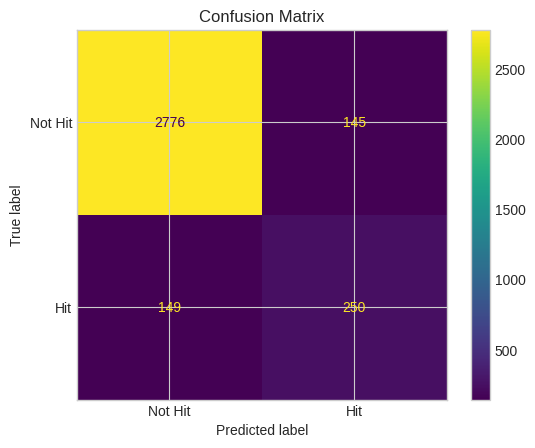

Confusion matrix visualized successfully.


In [ ]:
# Cell 24: Confusion Matrix Visualization
# ====================================
# TASK: Visualize the confusion matrix

cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hit', 'Hit'])
display_cm.plot()
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix visualized successfully.")